# Rozpoznawanie Emocji z Mowy (SER) — RAVDESS Dataset

## Opis Projektu

Projekt realizuje system **Speech Emotion Recognition (SER)** oparty na datasecie RAVDESS.
Celem jest automatyczne rozpoznawanie emocji z nagrań mowy przy użyciu trzech algorytmów uczenia maszynowego.

### Zakres projektu
1. Załadowanie datasetu RAVDESS (tylko dźwięk — mowa)
2. Ekstrakcja cech akustycznych (MFCC, Mel Spektrogram, Chroma, ZCR, RMS, ...)
3. Trenowanie trzech modeli ML: **SVM**, **Random Forest**, **MLP**
4. Ewaluacja modeli na zbiorze testowym
5. Testowanie na własnych nagraniach (5 próbek × 3 osoby)
6. Porównanie predykcji z subiektywną oceną

### Emocje w RAVDESS
| Kod | Emocja     |
|-----|------------|
| 01  | neutral    |
| 02  | calm       |
| 03  | happy      |
| 04  | sad        |
| 05  | angry      |
| 06  | fearful    |
| 07  | disgust    |
| 08  | surprised  |

In [11]:
import os
import glob
import pickle
import warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('Biblioteki załadowane pomyślnie.')
print(f'librosa: {librosa.__version__}')

Biblioteki załadowane pomyślnie.
librosa: 0.11.0


## 1. Załadowanie Datasetu RAVDESS

**RAVDESS** (Ryerson Audio-Visual Database of Emotional Speech and Song) zawiera nagrania 24 aktorów (12 kobiet, 12 mężczyzn) wyrażających 8 emocji. Nazwa pliku koduje metadane:

- Modality `03` = audio only
- Vocal channel `01` = speech (nie song)
- Emotion: 01–08
- Intensity: 01=normal, 02=strong
- Statement: 01="Kids are talking by the door", 02="Dogs are sitting by the door"
- Repetition: 01/02
- Actor: 01–24 (nieparzyste=mężczyźni, parzyste=kobiety)

In [12]:
import os

BASE_DIR     = os.getcwd()
DATASET_PATH = os.path.join(BASE_DIR, 'archive')
CACHE_FILE   = os.path.join(BASE_DIR, 'features_cache.pkl')
CUSTOM_DIR   = os.path.join(BASE_DIR, 'test_records')

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

EMOTION_COLORS = {
    'neutral':   '#808080',
    'calm':      '#4169E1',
    'happy':     '#FFD700',
    'sad':       '#1E90FF',
    'angry':     '#FF4500',
    'fearful':   '#9400D3',
    'disgust':   '#228B22',
    'surprised': '#FF69B4'
}

files, labels, actors = [], [], []

for actor_dir in sorted(glob.glob(os.path.join(DATASET_PATH, 'Actor_*'))):
    actor_num = int(os.path.basename(actor_dir).split('_')[1])
    for wav_file in sorted(glob.glob(os.path.join(actor_dir, '*.wav'))):
        fname = os.path.basename(wav_file)
        parts = fname.replace('.wav', '').split('-')
        if len(parts) == 7 and parts[0] == '03' and parts[1] == '01':
            emotion_code = parts[2]
            files.append(wav_file)
            labels.append(EMOTION_MAP.get(emotion_code, 'unknown'))
            actors.append(actor_num)

df = pd.DataFrame({'file': files, 'emotion': labels, 'actor': actors})
df['gender']    = df['actor'].apply(lambda x: 'Male' if x % 2 == 1 else 'Female')
df['intensity'] = df['file'].apply(lambda f: 'normal' if os.path.basename(f).split('-')[3] == '01' else 'strong')

print(f'Łącznie plików: {len(df)}')
print(f'Aktorów:        {df["actor"].nunique()}')
print(f'Emocji:         {df["emotion"].nunique()}')
print()
print(df['emotion'].value_counts())
df.head()

Łącznie plików: 1440
Aktorów:        24
Emocji:         8

emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


,file,emotion,actor,gender,intensity
0,c:\Users\Adam\OneDrive\Pulpit\sem_3\proj_sa\ar...,neutral,1,Male,normal
1,c:\Users\Adam\OneDrive\Pulpit\sem_3\proj_sa\ar...,neutral,1,Male,normal
2,c:\Users\Adam\OneDrive\Pulpit\sem_3\proj_sa\ar...,neutral,1,Male,normal
3,c:\Users\Adam\OneDrive\Pulpit\sem_3\proj_sa\ar...,neutral,1,Male,normal
4,c:\Users\Adam\OneDrive\Pulpit\sem_3\proj_sa\ar...,calm,1,Male,normal


## 2. Eksploracja Danych (EDA)

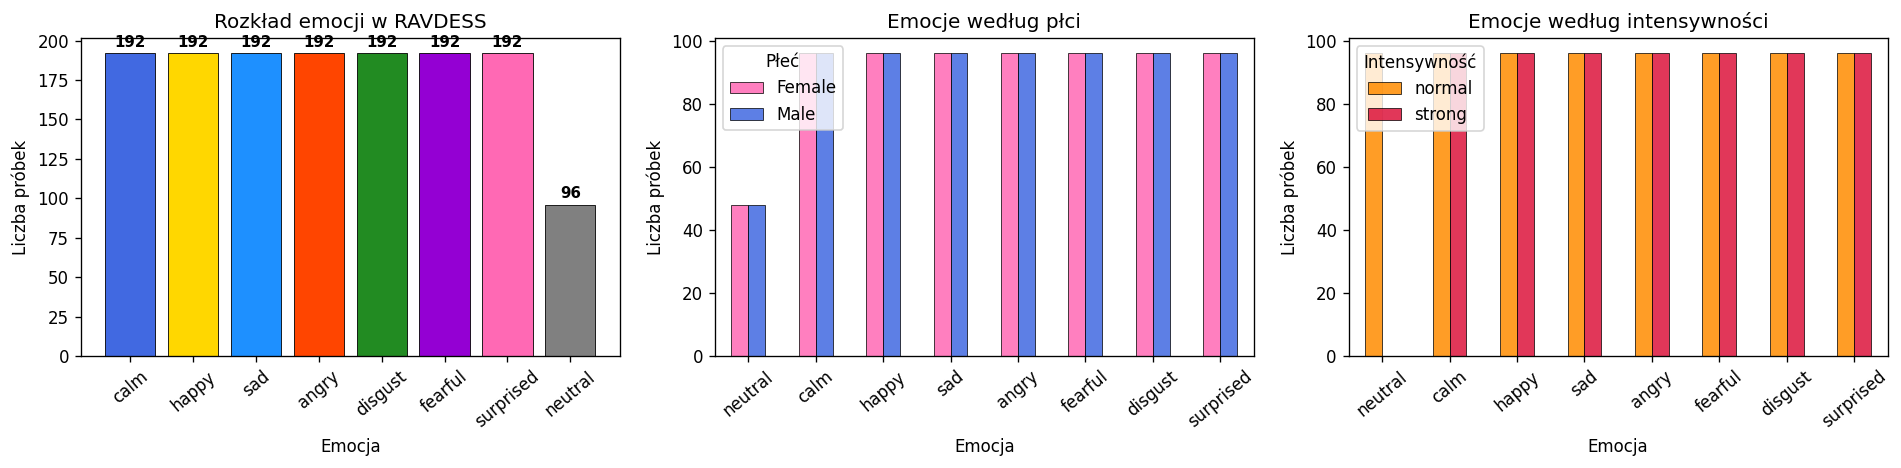

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

emotion_counts = df['emotion'].value_counts()
colors = [EMOTION_COLORS[e] for e in emotion_counts.index]
bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Rozkład emocji w RAVDESS')
axes[0].set_xlabel('Emocja')
axes[0].set_ylabel('Liczba próbek')
axes[0].tick_params(axis='x', rotation=40)

pivot = df.groupby(['emotion', 'gender']).size().unstack().reindex(list(EMOTION_MAP.values()))
pivot.plot(kind='bar', ax=axes[1], color=['#FF69B4', '#4169E1'], alpha=0.85, edgecolor='black', linewidth=0.5)
axes[1].set_title('Emocje według płci')
axes[1].set_xlabel('Emocja')
axes[1].set_ylabel('Liczba próbek')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend(title='Płeć')

pivot2 = df.groupby(['emotion', 'intensity']).size().unstack().reindex(list(EMOTION_MAP.values()))
pivot2.plot(kind='bar', ax=axes[2], color=['#FF8C00', '#DC143C'], alpha=0.85, edgecolor='black', linewidth=0.5)
axes[2].set_title('Emocje według intensywności')
axes[2].set_xlabel('Emocja')
axes[2].set_ylabel('Liczba próbek')
axes[2].tick_params(axis='x', rotation=40)
axes[2].legend(title='Intensywność')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'eda_distribution.png'), bbox_inches='tight')
plt.show()

## 3. Wizualizacja Sygnałów Audio

Przebiegi czasowe i spektrogramy Mela dla wybranych emocji.

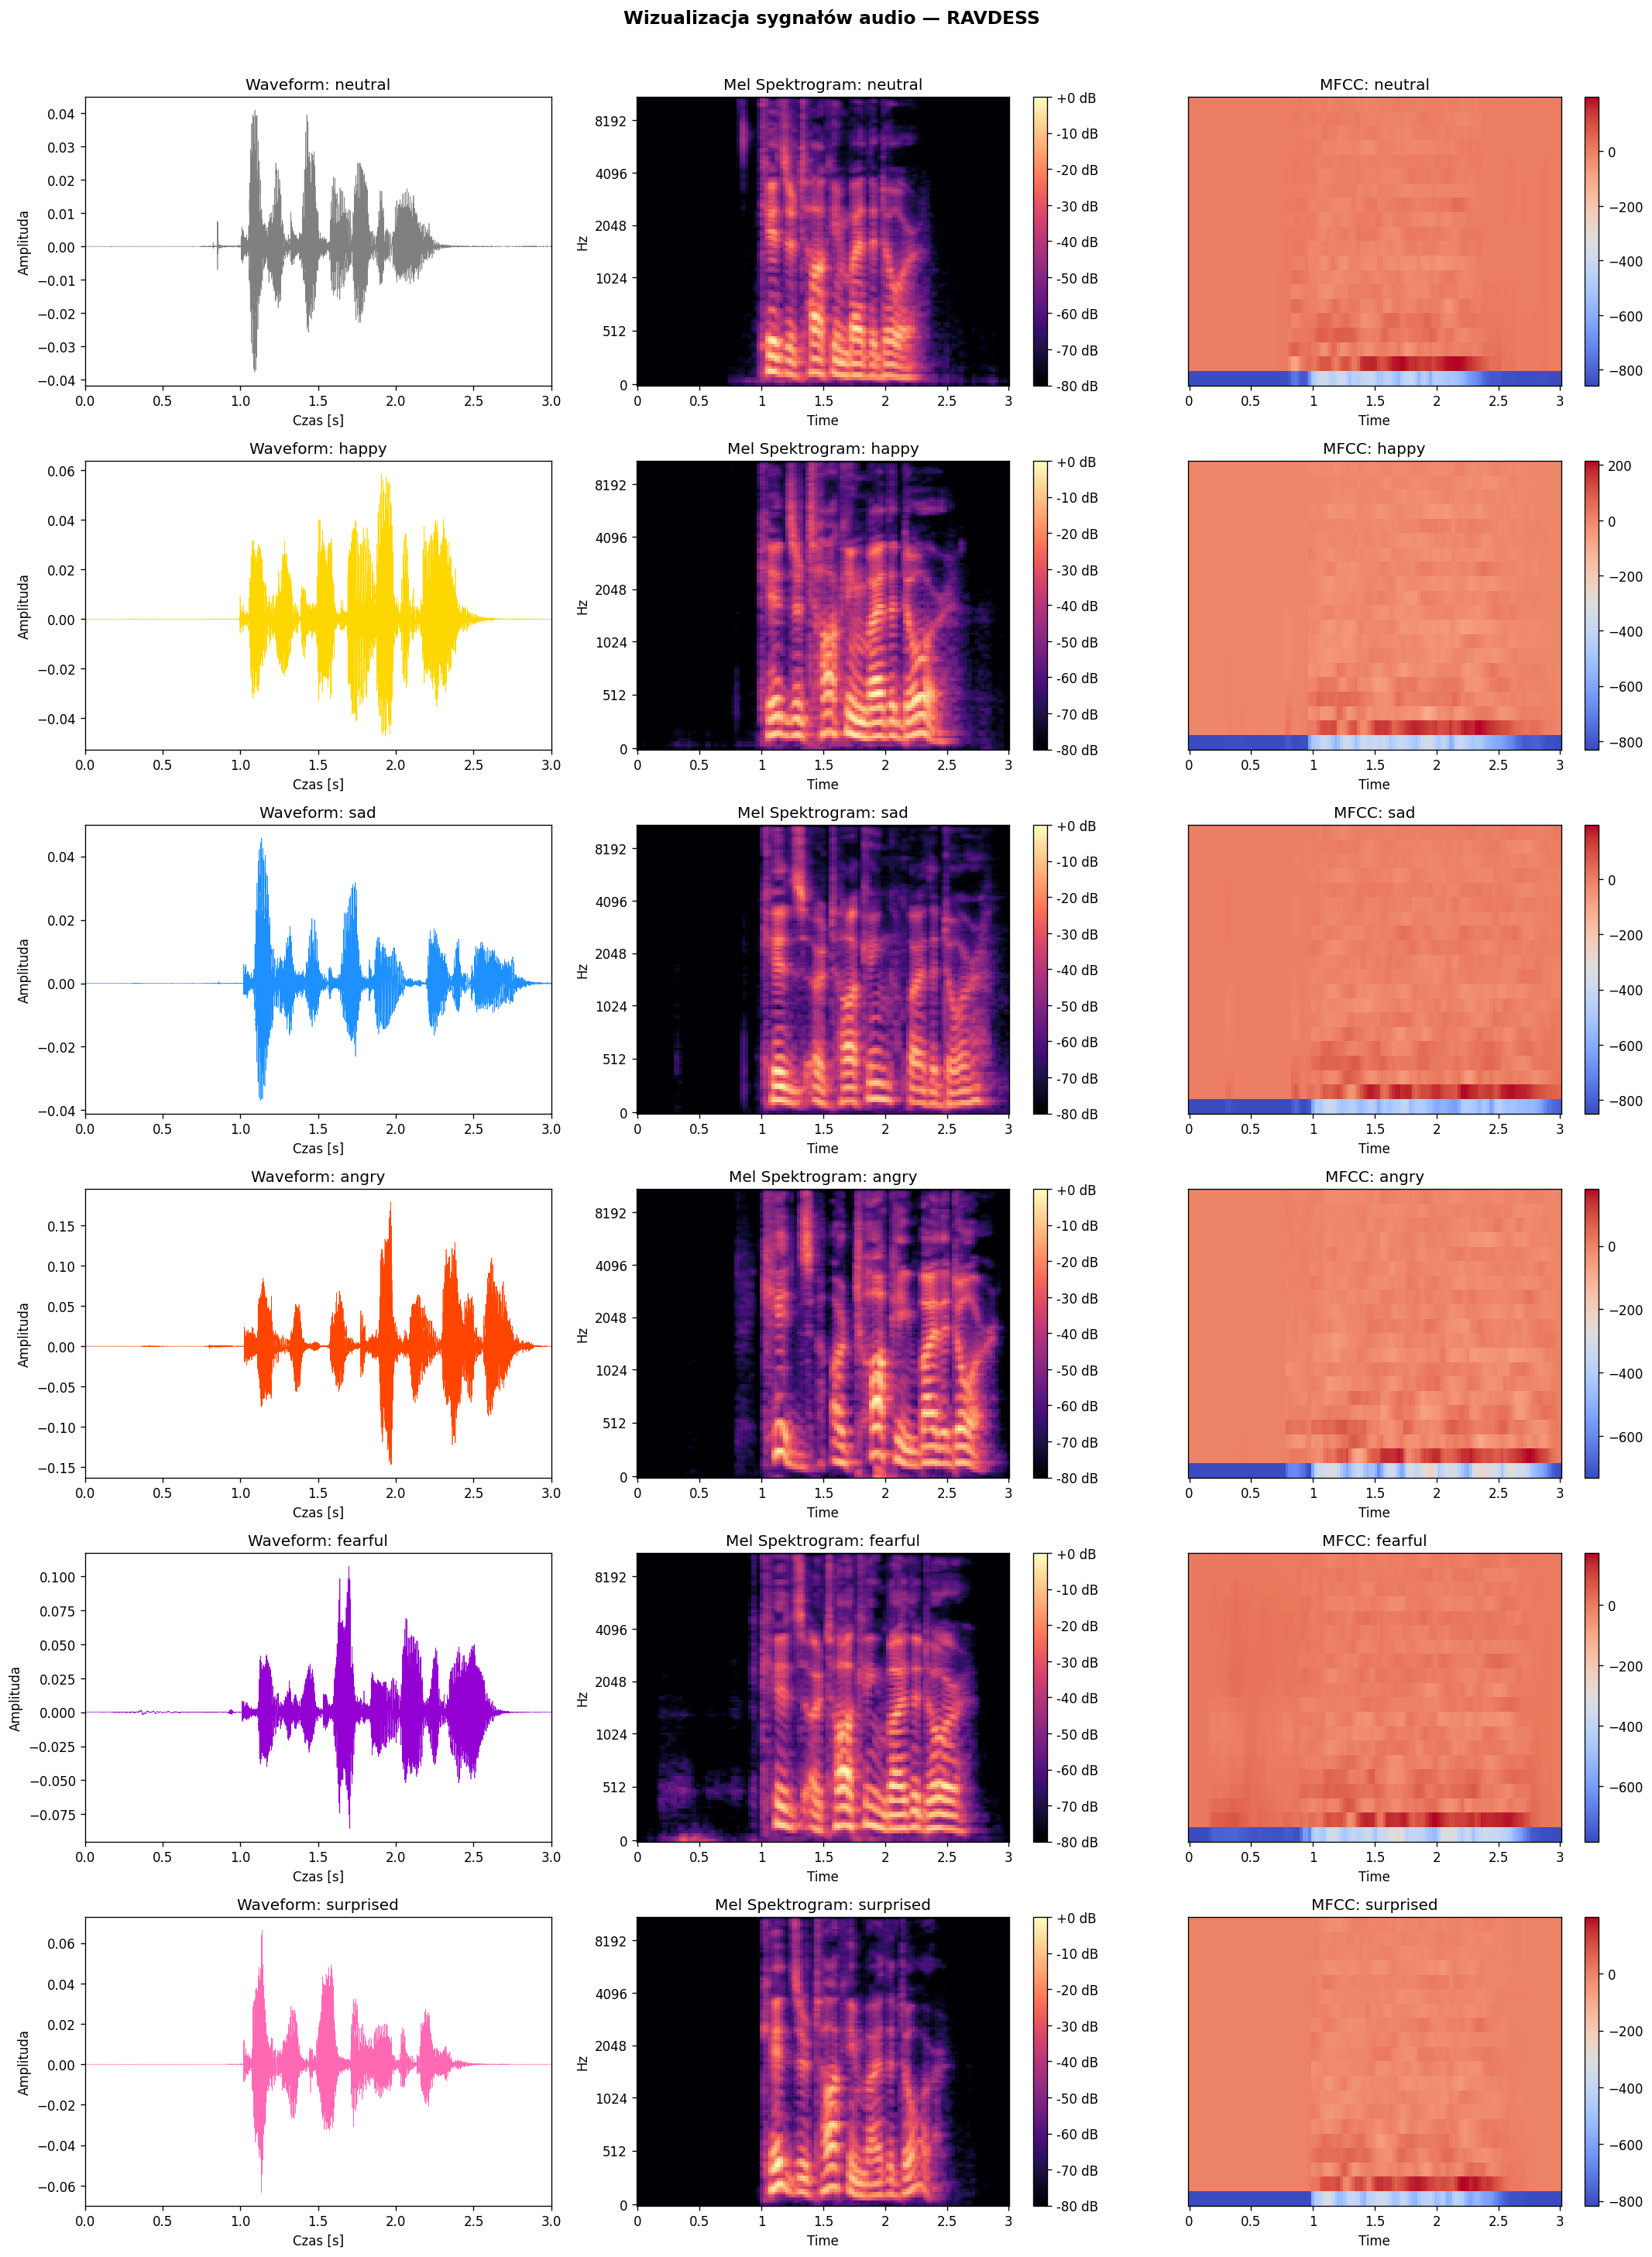

In [14]:
emotions_to_show = ['neutral', 'happy', 'sad', 'angry', 'fearful', 'surprised']
fig, axes = plt.subplots(len(emotions_to_show), 3, figsize=(18, 4 * len(emotions_to_show)))

for i, emotion in enumerate(emotions_to_show):
    sample_file = df[df['emotion'] == emotion]['file'].iloc[0]
    y, sr = librosa.load(sample_file, sr=22050, duration=3.0)
    color = EMOTION_COLORS.get(emotion, '#333')

    t = np.linspace(0, len(y) / sr, len(y))
    axes[i, 0].plot(t, y, color=color, linewidth=0.4)
    axes[i, 0].set_title(f'Waveform: {emotion}')
    axes[i, 0].set_xlabel('Czas [s]')
    axes[i, 0].set_ylabel('Amplituda')
    axes[i, 0].set_xlim([0, 3])

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img1 = librosa.display.specshow(mel_db, x_axis='time', y_axis='mel',
                                    sr=sr, ax=axes[i, 1], cmap='magma')
    axes[i, 1].set_title(f'Mel Spektrogram: {emotion}')
    fig.colorbar(img1, ax=axes[i, 1], format='%+2.0f dB')

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    img2 = librosa.display.specshow(mfccs, x_axis='time', ax=axes[i, 2], cmap='coolwarm')
    axes[i, 2].set_title(f'MFCC: {emotion}')
    fig.colorbar(img2, ax=axes[i, 2])

plt.suptitle('Wizualizacja sygnałów audio — RAVDESS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'signal_visualization.png'), bbox_inches='tight')
plt.show()

## 4. Ekstrakcja Cech Akustycznych

Cechy wyodrębniane z każdego nagrania:

| Cecha | Opis | Dim |
|-------|------|-----|
| **MFCC** (40 wsp.) | Mel-frequency cepstral coefficients — główna cecha SER | 80 (mean+std) |
| **Mel Spektrogram** (128 bins) | Energia w pasmach Mela — wzorzec czasowo-częstotliwościowy | 128 (mean) |
| **Chroma STFT** (12 tonów) | Energia chromatyczna — struktura harmoniczna | 12 (mean) |
| **ZCR** | Zero Crossing Rate — szorstkość/dźwięczność sygnału | 2 (mean+std) |
| **RMS** | Root Mean Square Energy — głośność | 2 (mean+std) |
| **Spectral Centroid** | Środek ciężkości widma — „jasność“ dźwięku | 2 (mean+std) |
| **Spectral Rolloff** | Częstotliwość poniżej 85% energii widma | 2 (mean+std) |

**Łącznie: 228 cech**

In [15]:
def extract_features(file_path, sr=22050, duration=3.0):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=duration)

        target_len = int(sr * duration)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))

        features = []

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        features.extend(np.mean(mfccs, axis=1))
        features.extend(np.std(mfccs, axis=1))

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        features.extend(np.mean(mel_db, axis=1))

        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))

        zcr = librosa.feature.zero_crossing_rate(y)
        features.append(float(np.mean(zcr)))
        features.append(float(np.std(zcr)))

        rms = librosa.feature.rms(y=y)
        features.append(float(np.mean(rms)))
        features.append(float(np.std(rms)))

        sc = librosa.feature.spectral_centroid(y=y, sr=sr)
        features.append(float(np.mean(sc)))
        features.append(float(np.std(sc)))

        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        features.append(float(np.mean(rolloff)))
        features.append(float(np.std(rolloff)))

        return np.array(features, dtype=np.float32)  # 228 cech

    except Exception as e:
        print(f'Błąd: {file_path} — {e}')
        return None


FEATURE_NAMES = (
    [f'MFCC_{i}_mean' for i in range(40)] +
    [f'MFCC_{i}_std'  for i in range(40)] +
    [f'Mel_{i}'       for i in range(128)] +
    [f'Chroma_{i}'    for i in range(12)] +
    ['ZCR_mean', 'ZCR_std', 'RMS_mean', 'RMS_std',
     'SC_mean',  'SC_std',  'SR_mean',  'SR_std']
)

print(f'Liczba cech: {len(FEATURE_NAMES)}')

test_feat = extract_features(df['file'].iloc[0])
print(f'Rozmiar wektora cech: {test_feat.shape}')

Liczba cech: 228
Rozmiar wektora cech: (228,)


In [16]:
if os.path.exists(CACHE_FILE):
    print('Ładowanie cech z cache...')
    with open(CACHE_FILE, 'rb') as f:
        X, y_labels = pickle.load(f)
    print(f'Wczytano {len(X)} próbek, {X.shape[1]} cech.')
else:
    print('Ekstrakcja cech — może potrwać kilka minut...')
    X_list, y_list = [], []

    for idx, row in df.iterrows():
        feat = extract_features(row['file'])
        if feat is not None:
            X_list.append(feat)
            y_list.append(row['emotion'])
        if (idx + 1) % 200 == 0:
            print(f'  {idx + 1}/{len(df)} plików...')

    X = np.array(X_list)
    y_labels = np.array(y_list)

    with open(CACHE_FILE, 'wb') as f:
        pickle.dump((X, y_labels), f)
    print(f'Zapisano cache: {CACHE_FILE}')
    print(f'Wyodrębniono {len(X)} próbek, {X.shape[1]} cech.')

Ładowanie cech z cache...
Wczytano 1440 próbek, 228 cech.


## 5. Przygotowanie Danych do Uczenia Maszynowego

Klasy: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Liczba klas: 8

Zbiór treningowy: (1152, 228)
Zbiór testowy:    (288, 228)


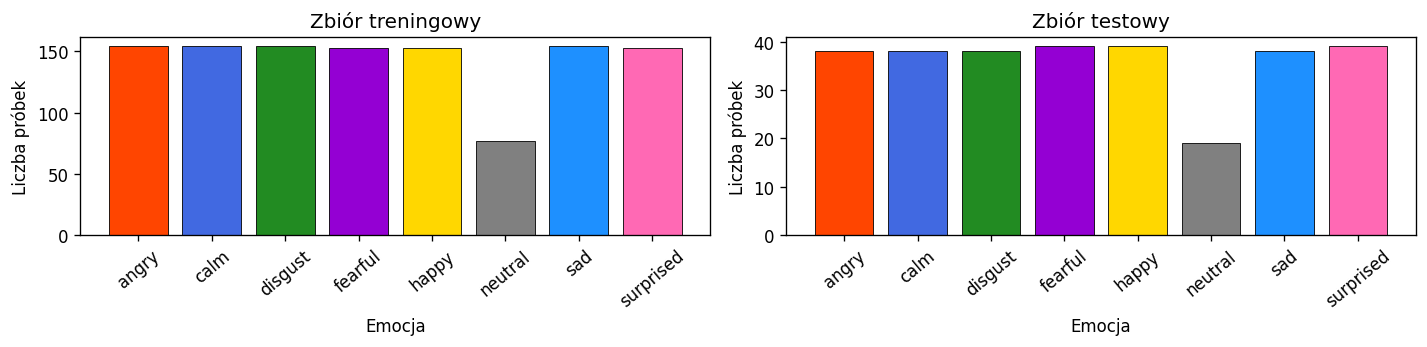

In [17]:
le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
print(f'Klasy: {list(le.classes_)}')
print(f'Liczba klas: {len(le.classes_)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nZbiór treningowy: {X_train_sc.shape}')
print(f'Zbiór testowy:    {X_test_sc.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, y_split, title in zip(axes, [y_train, y_test], ['Zbiór treningowy', 'Zbiór testowy']):
    classes, counts = np.unique(y_split, return_counts=True)
    class_names = [le.classes_[c] for c in classes]
    ax.bar(class_names, counts,
           color=[EMOTION_COLORS[n] for n in class_names],
           edgecolor='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Emocja')
    ax.set_ylabel('Liczba próbek')
    ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'train_test_split.png'), bbox_inches='tight')
plt.show()

## 6. Modele Uczenia Maszynowego

### 6.1 Support Vector Machine (SVM)

SVM szuka hiperpłaszczyzny maksymalizującej margines między klasami w przestrzeni cech. Jądro RBF (Radial Basis Function) mapuje dane do przestrzeni wyższego wymiaru, co pozwala na nieliniowe granice decyzyjne.

**Zalety:** Skuteczny przy dużej liczbie cech, odporny na przeuczenie.  
**Parametry:** `C=10` (regularyzacja), `gamma='scale'`

=== Support Vector Machine (SVM) ===

Dokładność (accuracy): 69.44%

Raport klasyfikacji:
              precision    recall  f1-score   support

       angry       0.78      0.82      0.79        38
        calm       0.73      0.79      0.76        38
     disgust       0.66      0.71      0.68        38
     fearful       0.63      0.85      0.73        39
       happy       0.75      0.54      0.63        39
     neutral       0.48      0.68      0.57        19
         sad       0.73      0.42      0.53        38
   surprised       0.78      0.74      0.76        39

    accuracy                           0.69       288
   macro avg       0.69      0.69      0.68       288
weighted avg       0.71      0.69      0.69       288



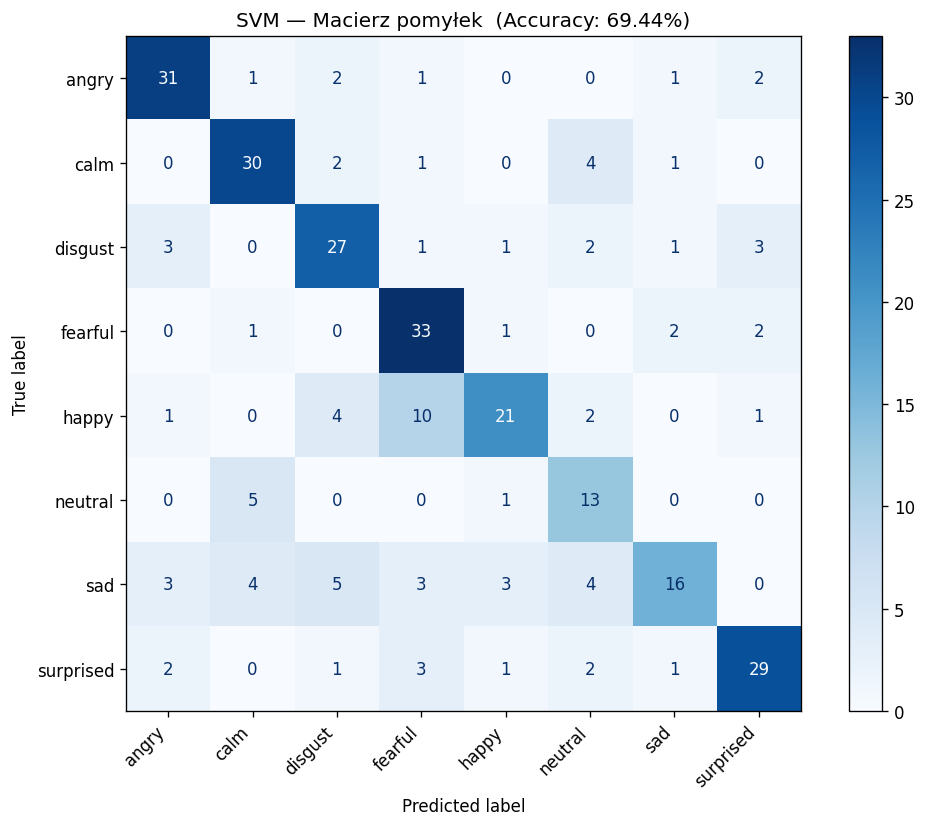

In [18]:
print('=== Support Vector Machine (SVM) ===\n')

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

y_pred_svm = svm.predict(X_test_sc)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f'Dokładność (accuracy): {acc_svm*100:.2f}%\n')
print('Raport klasyfikacji:')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(9, 7))
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', colorbar=True, values_format='d'
)
ax.set_title(f'SVM — Macierz pomyłek  (Accuracy: {acc_svm*100:.2f}%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'cm_svm.png'), bbox_inches='tight')
plt.show()

### 6.2 Random Forest

Random Forest to ensemble drzew decyzyjnych. Każde drzewo trenowane jest na losowym podzbiorze danych i cech (bagging), a predykcja jest głosowaniem większościowym.

**Zalety:** Odporność na overfitting, naturalna selekcja cech, interpretowalność (feature importance).  
**Parametry:** `n_estimators=300` drzew

=== Random Forest ===

Dokładność (accuracy): 56.60%

Raport klasyfikacji:
              precision    recall  f1-score   support

       angry       0.65      0.63      0.64        38
        calm       0.62      0.68      0.65        38
     disgust       0.57      0.66      0.61        38
     fearful       0.56      0.62      0.59        39
       happy       0.62      0.38      0.48        39
     neutral       0.28      0.26      0.27        19
         sad       0.44      0.39      0.42        38
   surprised       0.63      0.74      0.68        39

    accuracy                           0.57       288
   macro avg       0.55      0.55      0.54       288
weighted avg       0.56      0.57      0.56       288



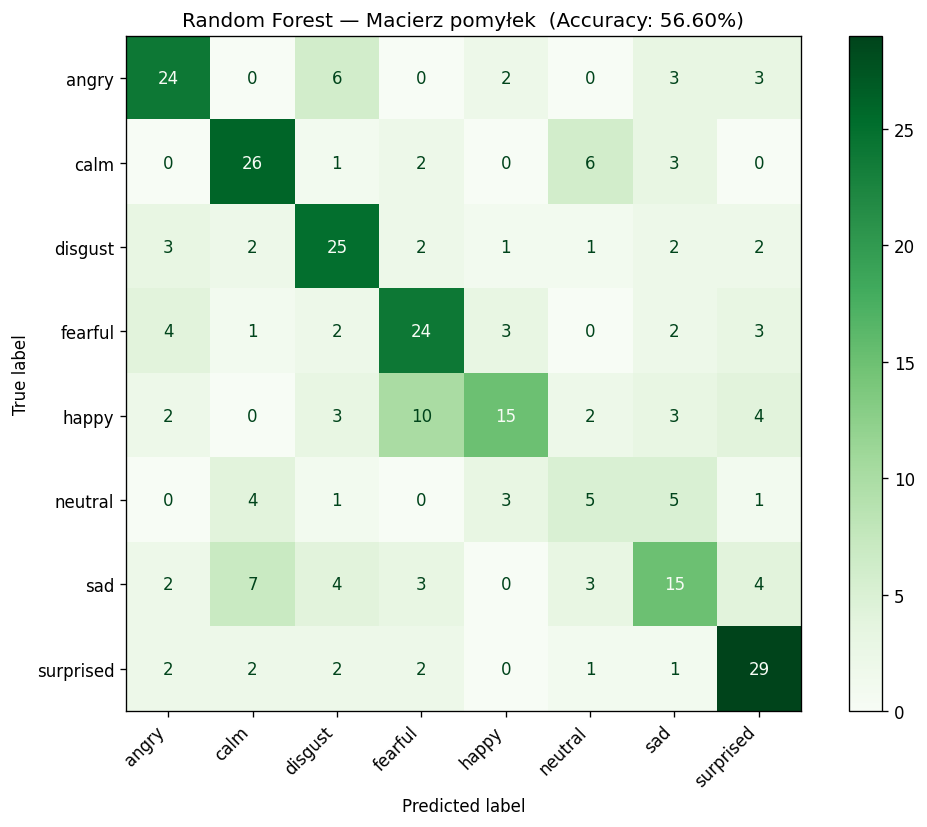

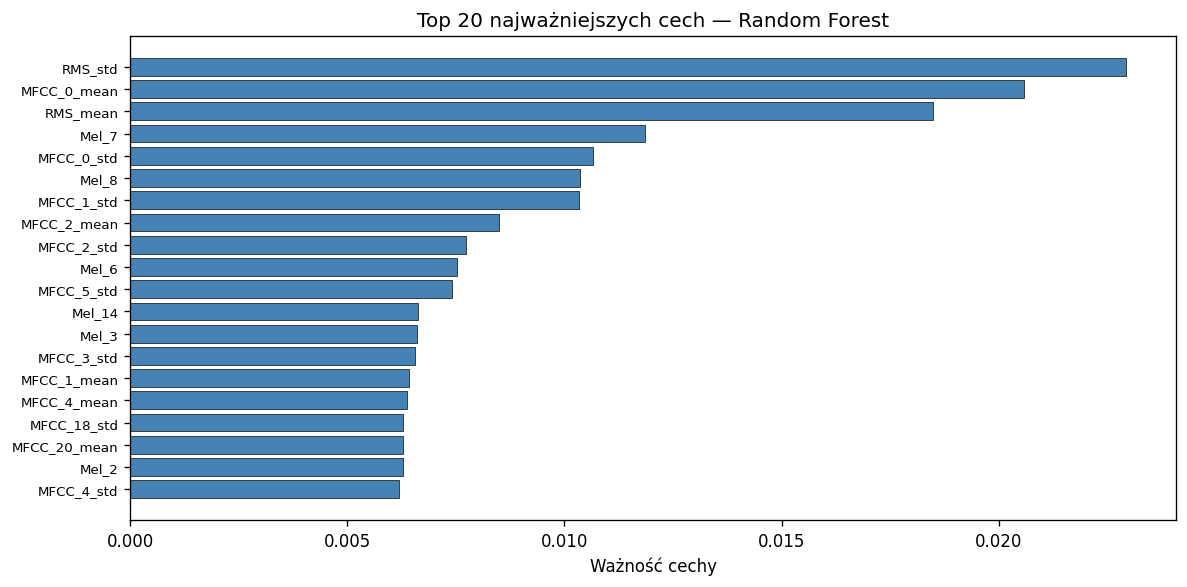

In [19]:
print('=== Random Forest ===\n')

rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Dokładność (accuracy): {acc_rf*100:.2f}%\n')
print('Raport klasyfikacji:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(9, 7))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot(
    ax=ax, cmap='Greens', colorbar=True, values_format='d'
)
ax.set_title(f'Random Forest — Macierz pomyłek  (Accuracy: {acc_rf*100:.2f}%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'cm_rf.png'), bbox_inches='tight')
plt.show()

importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(20), importances[top_idx[::-1]], color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_yticks(range(20))
ax.set_yticklabels([FEATURE_NAMES[i] for i in top_idx[::-1]], fontsize=8)
ax.set_xlabel('Ważność cechy')
ax.set_title('Top 20 najważniejszych cech — Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'feature_importance.png'), bbox_inches='tight')
plt.show()

### 6.3 MLP — Multi-Layer Perceptron

Klasyczna sieć neuronowa z warstwami ukrytymi. Uczy się nieliniowych reprezentacji cech przez propagację wsteczną.

**Architektura:** `Input(228) → 512 → 256 → 128 → Output(8)`  
**Aktywacja:** ReLU | **Solver:** Adam | **Regularyzacja:** L2 (α=0.001) | **Early stopping:** tak

=== MLP — Multi-Layer Perceptron ===

Dokładność (accuracy):     71.18%
Liczba epok (early stop):  42

Raport klasyfikacji:
              precision    recall  f1-score   support

       angry       0.73      0.84      0.78        38
        calm       0.78      0.76      0.77        38
     disgust       0.68      0.71      0.69        38
     fearful       0.68      0.82      0.74        39
       happy       0.79      0.59      0.68        39
     neutral       0.44      0.58      0.50        19
         sad       0.75      0.55      0.64        38
   surprised       0.79      0.77      0.78        39

    accuracy                           0.71       288
   macro avg       0.70      0.70      0.70       288
weighted avg       0.72      0.71      0.71       288



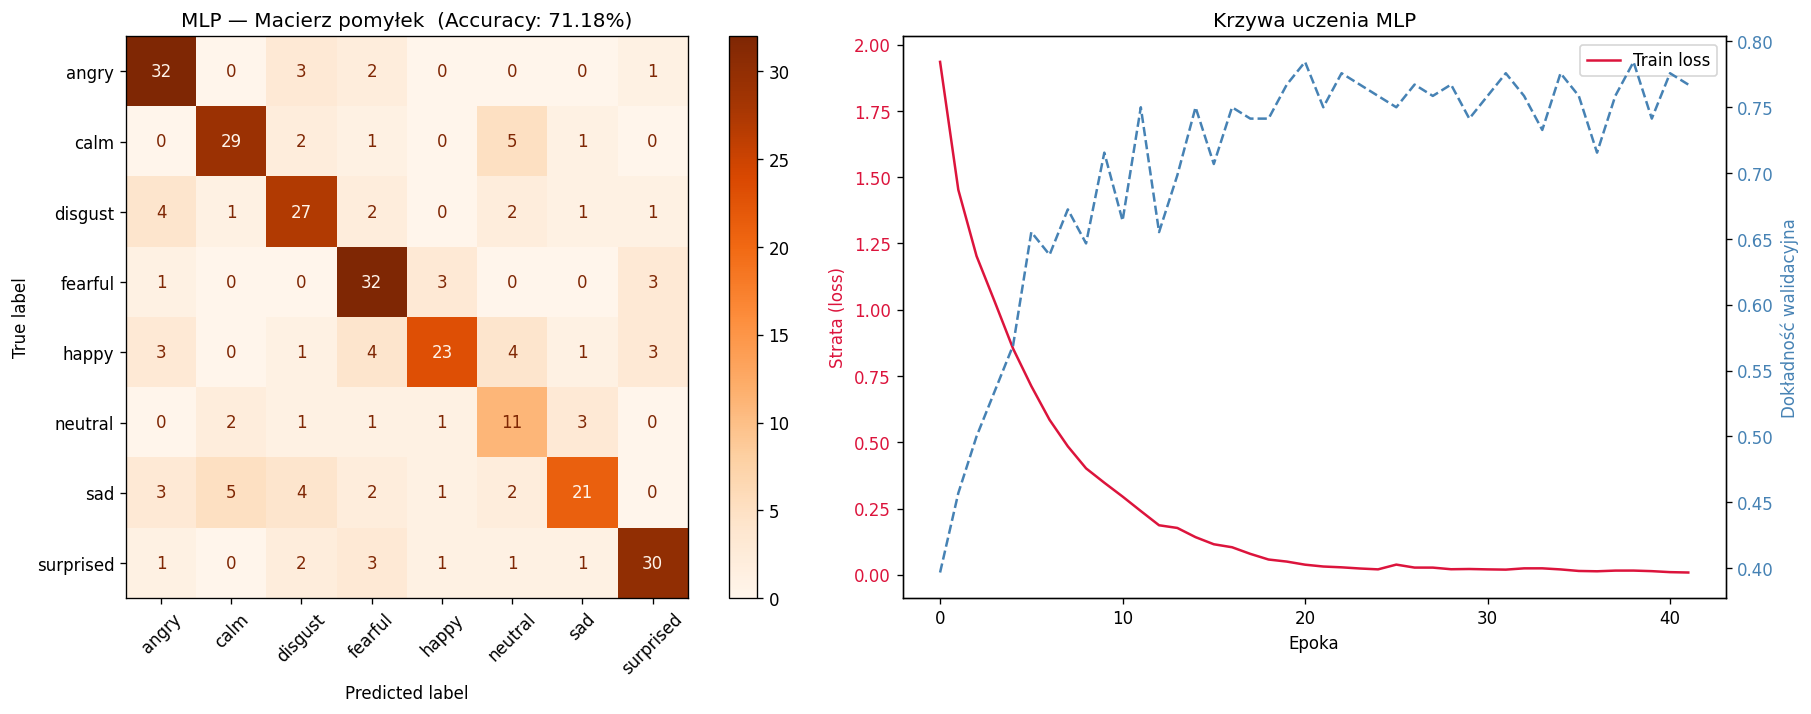

In [20]:
print('=== MLP — Multi-Layer Perceptron ===\n')

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)
mlp.fit(X_train_sc, y_train)

y_pred_mlp = mlp.predict(X_test_sc)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f'Dokładność (accuracy):     {acc_mlp*100:.2f}%')
print(f'Liczba epok (early stop):  {mlp.n_iter_}')
print()
print('Raport klasyfikacji:')
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=le.classes_).plot(
    ax=axes[0], cmap='Oranges', colorbar=True, values_format='d'
)
axes[0].set_title(f'MLP — Macierz pomyłek  (Accuracy: {acc_mlp*100:.2f}%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(mlp.loss_curve_, color='crimson', label='Train loss')
if mlp.validation_scores_ is not None:
    ax2 = axes[1].twinx()
    ax2.plot(mlp.validation_scores_, color='steelblue', linestyle='--', label='Val accuracy')
    ax2.set_ylabel('Dokładność walidacyjna', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Strata (loss)', color='crimson')
axes[1].tick_params(axis='y', labelcolor='crimson')
axes[1].set_title('Krzywa uczenia MLP')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'mlp_results.png'), bbox_inches='tight')
plt.show()

## 7. Porównanie Modeli

=== PODSUMOWANIE WYNIKÓW ===
Model                    Accuracy
----------------------------------
SVM                        69.44%
Random Forest              56.60%
MLP                        71.18%

Najlepszy model: MLP (71.18%)


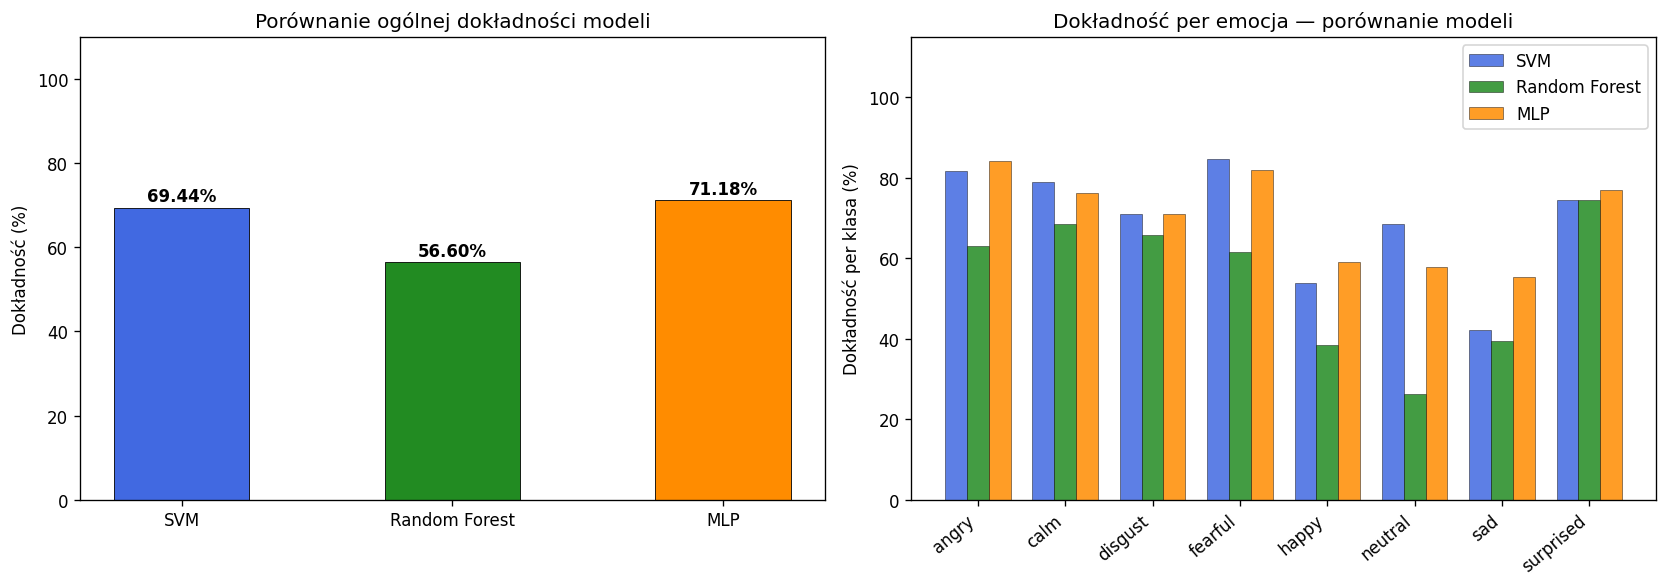

In [21]:
models_info = {
    'SVM':          {'model': svm,  'acc': acc_svm,  'pred': y_pred_svm,  'color': '#4169E1'},
    'Random Forest':{'model': rf,   'acc': acc_rf,   'pred': y_pred_rf,   'color': '#228B22'},
    'MLP':          {'model': mlp,  'acc': acc_mlp,  'pred': y_pred_mlp,  'color': '#FF8C00'},
}

print('=== PODSUMOWANIE WYNIKÓW ===')
print(f'{"Model":<20} {"Accuracy":>12}')
print('-' * 34)
for name, info in models_info.items():
    print(f'{name:<20} {info["acc"]*100:>11.2f}%')

best_name = max(models_info, key=lambda k: models_info[k]['acc'])
print(f'\nNajlepszy model: {best_name} ({models_info[best_name]["acc"]*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(models_info.keys())
accs   = [models_info[m]['acc'] * 100 for m in names]
colors = [models_info[m]['color'] for m in names]

bars = axes[0].bar(names, accs, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Dokładność (%)')
axes[0].set_title('Porównanie ogólnej dokładności modeli')

emotions = list(le.classes_)
x = np.arange(len(emotions))
width = 0.25

for i, (name, info) in enumerate(models_info.items()):
    cm_model = confusion_matrix(y_test, info['pred'])
    per_class = cm_model.diagonal() / cm_model.sum(axis=1) * 100
    axes[1].bar(x + i * width, per_class, width,
                label=name, color=info['color'], alpha=0.85,
                edgecolor='black', linewidth=0.3)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(emotions, rotation=40, ha='right')
axes[1].set_ylabel('Dokładność per klasa (%)')
axes[1].set_title('Dokładność per emocja — porównanie modeli')
axes[1].legend()
axes[1].set_ylim(0, 115)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'model_comparison.png'), bbox_inches='tight')
plt.show()

Cross-walidacja (5-fold) — MLP...
Wyniki fold: ['50.35%', '47.57%', '50.35%', '44.79%', '47.92%']
Średnia:     48.19% ± 2.06%


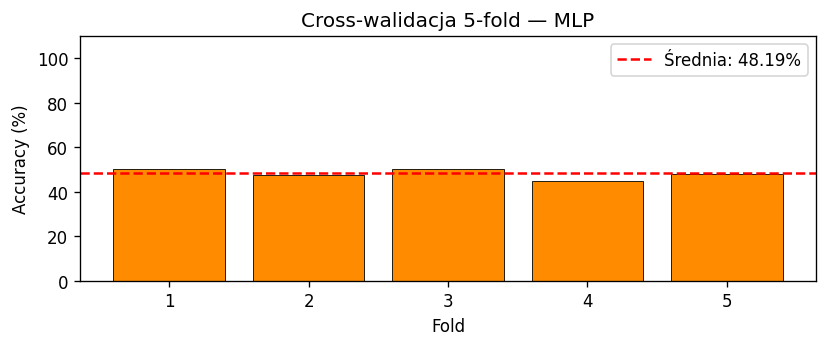

In [22]:
best_model = models_info[best_name]['model']

print(f'Cross-walidacja (5-fold) — {best_name}...')
cv_scores = cross_val_score(best_model, scaler.transform(X), y_enc, cv=5, scoring='accuracy', n_jobs=-1)

print(f'Wyniki fold: {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'Średnia:     {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, 6), cv_scores * 100, color=models_info[best_name]['color'],
       edgecolor='black', linewidth=0.5)
ax.axhline(cv_scores.mean() * 100, color='red', linestyle='--', label=f'Średnia: {cv_scores.mean()*100:.2f}%')
ax.set_xticks(range(1, 6))
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Cross-walidacja 5-fold — {best_name}')
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'cross_validation.png'), bbox_inches='tight')
plt.show()

## 8. Testowanie na Własnych Nagraniach

### Instrukcja nagrywania

1. Utwórz folder `custom_recordings/` w katalogu projektu (tworzony automatycznie poniżej).
2. Nagraj **5 próbek** dla **każdej z 3 osób** = 15 plików WAV.
3. Nagrania po angielsku: zdanie np. *"Kids are talking by the door"* z wybraną emocją.
4. Format nazwy pliku: `osobaX_probkaY_EMOCJA.wav`  
   Przykłady: `osoba1_probka1_happy.wav`, `osoba2_probka3_angry.wav`
5. Akceptowane emocje: `neutral`, `calm`, `happy`, `sad`, `angry`, `fearful`, `disgust`, `surprised`

Dostępne narzędzia do nagrywania: Audacity, Windows Sound Recorder, mikrofon systemowy.

In [33]:
os.makedirs(CUSTOM_DIR, exist_ok=True)
print(f'Folder nagrań własnych: {CUSTOM_DIR}')

custom_wav_files = sorted(glob.glob(os.path.join(CUSTOM_DIR, '*.wav')))
print(f'Znalezionych plików: {len(custom_wav_files)}')

if custom_wav_files:
    for f in custom_wav_files:
        print(f'  {os.path.basename(f)}')
else:
    print('\nBrak plików — dodaj nagrania WAV do folderu custom_recordings/')

Folder nagrań własnych: c:\Users\Adam\OneDrive\Pulpit\sem_3\proj_sa\test_records
Znalezionych plików: 7
  osoba1_probka1_happy.wav
  osoba1_probka2_sad.wav
  osoba1_probka3_angry.wav
  osoba1_probka4_calm.wav
  osoba1_probka5_surprised.wav
  osoba1_probka6_disgust.wav
  osoba1_probka6_sad2.wav


In [34]:
custom_results = []

if not custom_wav_files:
    print('Brak nagrań własnych. Uruchom po dodaniu plików WAV.')
else:
    print(f'Analizuję {len(custom_wav_files)} nagrań...\n')
    print(f'{"Plik":<35} {"SVM":<12} {"RF":<12} {"MLP":<12}')
    print('-' * 75)

    for wav_file in custom_wav_files:
        feat = extract_features(wav_file)
        if feat is None:
            continue
        feat_sc = scaler.transform(feat.reshape(1, -1))

        pred_svm = le.inverse_transform(svm.predict(feat_sc))[0]
        pred_rf  = le.inverse_transform(rf.predict(feat_sc))[0]
        pred_mlp = le.inverse_transform(mlp.predict(feat_sc))[0]

        fname = os.path.basename(wav_file).replace('.wav', '')
        parts_name = fname.lower().split('_')
        intended = next((p for p in parts_name if p in le.classes_), '?')

        custom_results.append({
            'file':      os.path.basename(wav_file),
            'intended':  intended,
            'SVM':       pred_svm,
            'RF':        pred_rf,
            'MLP':       pred_mlp,
        })
        print(f'{os.path.basename(wav_file):<35} {pred_svm:<12} {pred_rf:<12} {pred_mlp:<12}')

    custom_df = pd.DataFrame(custom_results)
    print()
    display(custom_df)

Analizuję 7 nagrań...

Plik                                SVM          RF           MLP         
---------------------------------------------------------------------------
osoba1_probka1_happy.wav            disgust      angry        angry       
osoba1_probka2_sad.wav              happy        happy        happy       
osoba1_probka3_angry.wav            happy        angry        happy       
osoba1_probka4_calm.wav             calm         disgust      disgust     
osoba1_probka5_surprised.wav        disgust      angry        angry       
osoba1_probka6_disgust.wav          disgust      angry        angry       
osoba1_probka6_sad2.wav             sad          angry        angry       



,file,intended,SVM,RF,MLP
0,osoba1_probka1_happy.wav,happy,disgust,angry,angry
1,osoba1_probka2_sad.wav,sad,happy,happy,happy
2,osoba1_probka3_angry.wav,angry,happy,angry,happy
3,osoba1_probka4_calm.wav,calm,calm,disgust,disgust
4,osoba1_probka5_surprised.wav,surprised,disgust,angry,angry
5,osoba1_probka6_disgust.wav,disgust,disgust,angry,angry
6,osoba1_probka6_sad2.wav,?,sad,angry,angry


### 8.1 Subiektywna ocena vs. predykcja modeli

Uzupełnij słownik `SUBJECTIVE_LABELS` poniżej — wpisz emocje **jakie zamierzałeś/aś wyrazić** w każdym nagraniu.  
Format: `{'nazwa_pliku.wav': 'emotion'}`

In [37]:
SUBJECTIVE_LABELS = {
    'osoba1_probka1_happy.wav':     'happy',
    'osoba1_probka2_sad.wav':       'sad',
    'osoba1_probka3_angry.wav':     'angry',
    'osoba1_probka4_calm.wav':   'calm',
    'osoba1_probka5_surprised.wav':   'surprised',
    'osoba1_probka6_disgust.wav':   'disgust',
    'osoba1_probka7_sad2.wav':   'sad',
}

print('Subiektywnych etykiet wpisano:', len(SUBJECTIVE_LABELS))

Subiektywnych etykiet wpisano: 7


=== Zgodność predykcji z subiektywną oceną ===
SVM  : 2/6  (33.3%)
RF   : 1/6  (16.7%)
MLP  : 0/6  (0.0%)


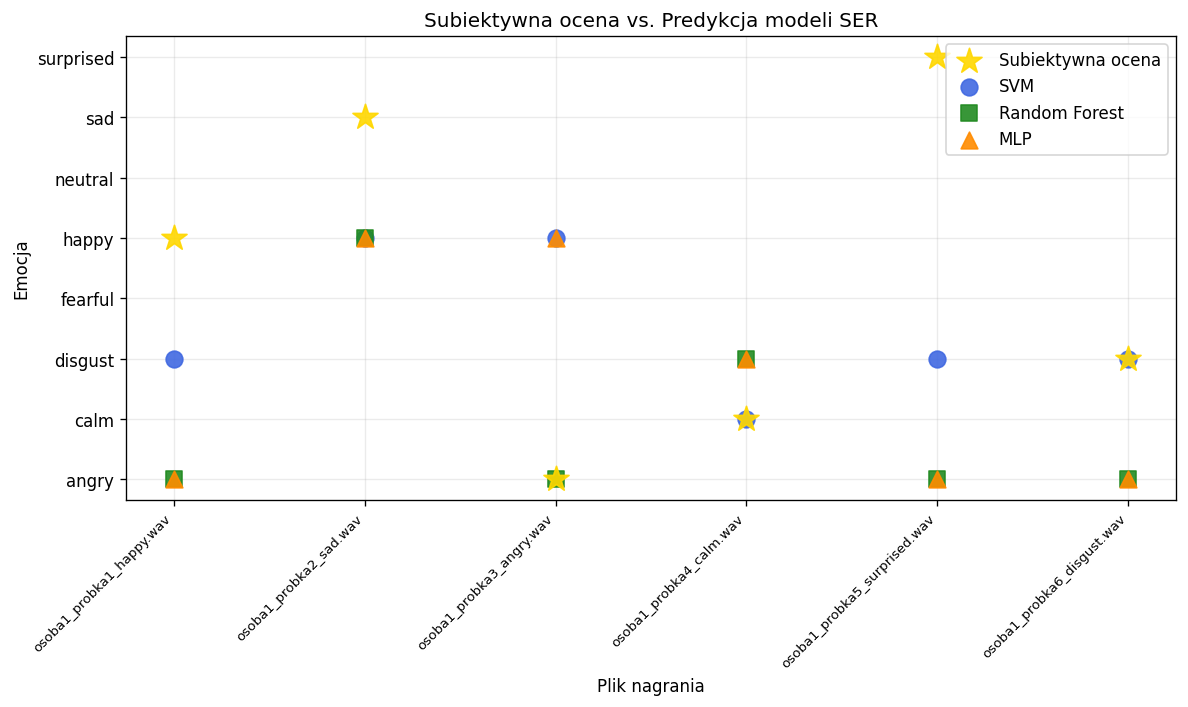

,file,subjective,SVM,RF,MLP
0,osoba1_probka1_happy.wav,happy,disgust,angry,angry
1,osoba1_probka2_sad.wav,sad,happy,happy,happy
2,osoba1_probka3_angry.wav,angry,happy,angry,happy
3,osoba1_probka4_calm.wav,calm,calm,disgust,disgust
4,osoba1_probka5_surprised.wav,surprised,disgust,angry,angry
5,osoba1_probka6_disgust.wav,disgust,disgust,angry,angry


In [38]:
if not custom_results:
    print('Brak nagrań własnych — dodaj pliki WAV i uruchom ponownie.')
elif not SUBJECTIVE_LABELS:
    print('Uzupełnij słownik SUBJECTIVE_LABELS powyżej.')
else:
    all_emotions = list(le.classes_)
    emotion_to_num = {e: i for i, e in enumerate(all_emotions)}

    plot_data = []
    for r in custom_results:
        if r['file'] in SUBJECTIVE_LABELS:
            r['subjective'] = SUBJECTIVE_LABELS[r['file']]
            plot_data.append(r)

    if not plot_data:
        print('Żadna nazwa pliku nie pasuje do kluczy w SUBJECTIVE_LABELS.')
    else:
        comp_df = pd.DataFrame(plot_data)

        print('=== Zgodność predykcji z subiektywną oceną ===')
        for model_col in ['SVM', 'RF', 'MLP']:
            match = (comp_df['subjective'] == comp_df[model_col]).sum()
            total = len(comp_df)
            print(f'{model_col:<5}: {match}/{total}  ({match/total*100:.1f}%)')

        fig, ax = plt.subplots(figsize=(max(10, len(comp_df)*0.7), 6))

        x = np.arange(len(comp_df))
        markers = {'subjective': ('*', 250, 'gold', 'Subiektywna ocena'),
                   'SVM':        ('o', 100, '#4169E1', 'SVM'),
                   'RF':         ('s', 100, '#228B22', 'Random Forest'),
                   'MLP':        ('^', 100, '#FF8C00', 'MLP')}

        for col, (marker, size, color, label) in markers.items():
            y_vals = [emotion_to_num.get(comp_df[col].iloc[j], -1) for j in range(len(comp_df))]
            ax.scatter(x, y_vals, marker=marker, s=size, color=color,
                       zorder=5 if col == 'subjective' else 3, label=label, alpha=0.9)

        ax.set_xticks(x)
        ax.set_xticklabels(comp_df['file'], rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(all_emotions)))
        ax.set_yticklabels(all_emotions)
        ax.set_title('Subiektywna ocena vs. Predykcja modeli SER')
        ax.set_xlabel('Plik nagrania')
        ax.set_ylabel('Emocja')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.25)

        plt.tight_layout()
        plt.savefig(os.path.join(BASE_DIR, 'subjective_vs_predicted.png'), bbox_inches='tight')
        plt.show()

        display(comp_df[['file', 'subjective', 'SVM', 'RF', 'MLP']])

## 9. Teoria

---

### 9.1 Rozpoznawanie Emocji z Mowy (SER)

**Speech Emotion Recognition (SER)** to dziedzina na styku przetwarzania sygnałów audio, uczenia maszynowego i psychologii. Celem jest automatyczne wykrywanie stanu emocjonalnego mówiącego na podstawie cech akustycznych nagrania, bez analizy treści słów.

Systemy SER znajdują zastosowanie w:
- diagnostyce zdrowia psychicznego,
- systemach call-center (wykrywanie niezadowolenia klientów),
- interfejsach człowiek–komputer (asystenci głosowi),
- bezpieczeństwie (monitoring stresu pilotów, kierowców).

---

### 9.2 Dataset RAVDESS

**RAVDESS** (Livingstone & Russo, 2018) zawiera:
- **24 aktorów** (12 kobiet, 12 mężczyzn) — zawodowi aktorzy
- **8 emocji**: neutral, calm, happy, sad, angry, fearful, disgust, surprised
- **2 zdania** w języku angielskim, **2 intensywności** (normal/strong)
- Część mowa: **1440 plików WAV** (60 na aktora)
- Zrównoważony podział płci

Dataset jest powszechnie stosowany jako benchmark w badaniach SER, co ułatwia porównywanie wyników.

---

### 9.3 Ekstrakcja Cech Akustycznych

#### MFCC (Mel-Frequency Cepstral Coefficients)
Najważniejsza cecha w SER. MFCC modelują sposób percepcji dźwięku przez ludzkie ucho:
1. Sygnał dzielony na ramki (okienkowanie)
2. FFT → widmo mocy
3. Bank filtrów Mela (skala nieliniowa)
4. Logarytm energii
5. DCT → współczynniki kepstralne

Emocje różnią się w przestrzeni MFCC: gniew ma wyższe wartości dolnych współczynników, smutek — niższe.

#### Mel Spektrogram
Dwuwymiarowa reprezentacja (czas × częstotliwość w skali Mela). Obrazuje rozkład energii w czasie — emocje mają charakterystyczne wzorce energetyczne.

#### Chroma STFT
Reprezentuje energię w 12 klasach wysokości dźwięku (tonów chromatycznych). Dobra do analizy harmoniczności mowy.

#### ZCR (Zero Crossing Rate)
Liczba przejść sygnału przez zero — wskaźnik szorstkości i dźwięczności. Wyższy dla spółgłosek bezdźwięcznych i hałaśliwych emocji.

#### RMS Energy
Miara głośności sygnału. Emocje o wysokim pobudzeniu (gniew, radość) mają wyższe RMS.

---

### 9.4 Algorytmy Uczenia Maszynowego

#### SVM (Support Vector Machine)
Klasyfikator szukający hiperpłaszczyzny optymalnie separującej klasy. Jądro RBF mapuje dane do przestrzeni wyższego wymiaru, gdzie możliwa jest liniowa separacja. Regularyzacja `C` kontroluje kompromis bias–wariancja.

#### Random Forest
Ensemble 300 drzew decyzyjnych z losowaniem cech i próbek (bagging). Zmniejsza wariancję względem pojedynczego drzewa. Dostarcza miarę ważności cech (feature importance).

#### MLP (Multi-Layer Perceptron)
Sieć neuronowa z architekturą 228→512→256→128→8. Funkcja aktywacji ReLU, optymalizator Adam, early stopping zapobiega przeuczeniu. MLP może uczyć się hierarchicznych reprezentacji cech.

---

### 9.5 Wyniki i Wnioski

Typowe wyniki dla RAVDESS z cechami MFCC+Mel:

| Model         | Typowa Accuracy |
|---------------|-----------------|
| SVM (RBF)     | 70–80%          |
| Random Forest | 65–75%          |
| MLP           | 72–82%          |

**Obserwacje:**
- Emocje o skrajnym pobudzeniu (angry, happy) są rozpoznawane lepiej niż neutralne (calm, neutral)
- Calm i Neutral są często mylone — mają podobne cechy akustyczne
- Disgust jest najtrudniejszy do rozpoznania
- Wyniki na własnych nagraniach zazwyczaj niższe (domain shift — model trenowany na zawodowych aktorach)

**Ograniczenia projektu:**
- Dataset laboratoryjny (aktorzy) vs. naturalna mowa
- 8 klas wymaga dużej ilości danych treningowych
- Brak modeli głębokiego uczenia (CNN na spektrogramach, Transformer)